# Train logistic regression model (t+3 target)
Train a logistic regression classifier on `data/processed/log_reg_t3`, using `target_t+3` as the label and all columns except the target, `client_nr`, and `yearmonth` as features.

Raw-magnitude features are standardized inside the pipeline (already-scaled z-scores/slopes and one-hot dummies are passed through), and `class_weight="balanced"` handles the rare positive class. Hyperparameters (`C`, `penalty`) are tuned with **Optuna**, maximizing PR-AUC on the validation split. The classification threshold is **not** tuned automatically: it is chosen manually below by inspecting the validation precision-recall curve.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# walk up to the project root so this notebook works from its subfolder
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "models").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / "models"))

import train_logistic_regression
from train_logistic_regression import (
    evaluate_all_splits,
    load_split,
    plot_precision_recall_curve,
    save_model,
    train_model,
)

HORIZON = "t3"
train_logistic_regression.set_horizon(HORIZON)
TARGET_COLUMN = train_logistic_regression.TARGET_COLUMN

c:\Users\SVisbee\Repos\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using dataset log_reg_t3 with target 'target_t+3'


## Tune hyperparameters and train

In [2]:
model, feature_columns, trials_df = train_model(n_trials=50)

Train observations: 18,664
Validation observations: 3,728
Number of features: 47

Class distribution in training data:
  Negative: 17,317
  Positive: 1,347


Best trial: 10. Best value: 0.137229: 100%|██████████| 50/50 [01:42<00:00,  2.05s/it]



Best validation PR-AUC: 0.1372
Best hyperparameters:
  C: 10.0
  penalty: l2


In [3]:
trials_df.sort_values("value", ascending=False).head(10)

,number,value,datetime_start,datetime_complete,duration,params_C,params_penalty,state
25,25,0.137229,2026-08-31 11:57:53.036937,2026-08-31 11:57:56.083907,0 days 00:00:03.046970,10.0,l2,COMPLETE
41,41,0.137229,2026-08-31 11:58:27.936840,2026-08-31 11:58:30.346483,0 days 00:00:02.409643,10.0,l2,COMPLETE
33,33,0.137229,2026-08-31 11:58:13.503935,2026-08-31 11:58:16.303522,0 days 00:00:02.799587,10.0,l2,COMPLETE
27,27,0.137229,2026-08-31 11:57:58.981167,2026-08-31 11:58:01.802919,0 days 00:00:02.821752,10.0,l2,COMPLETE
26,26,0.137229,2026-08-31 11:57:56.090952,2026-08-31 11:57:58.981167,0 days 00:00:02.890215,10.0,l2,COMPLETE
24,24,0.137229,2026-08-31 11:57:49.850349,2026-08-31 11:57:53.033923,0 days 00:00:03.183574,10.0,l2,COMPLETE
23,23,0.137229,2026-08-31 11:57:46.288417,2026-08-31 11:57:49.850349,0 days 00:00:03.561932,10.0,l2,COMPLETE
22,22,0.137229,2026-08-31 11:57:42.720916,2026-08-31 11:57:46.287411,0 days 00:00:03.566495,10.0,l2,COMPLETE
21,21,0.137229,2026-08-31 11:57:39.927602,2026-08-31 11:57:42.719411,0 days 00:00:02.791809,10.0,l2,COMPLETE
17,17,0.137229,2026-08-31 11:57:28.457263,2026-08-31 11:57:31.671249,0 days 00:00:03.213986,10.0,l2,COMPLETE


## Select the classification threshold
Inspect the precision-recall curve on the **validation** split (train would be optimistic, test must stay untouched) and pick the threshold matching the business objective.

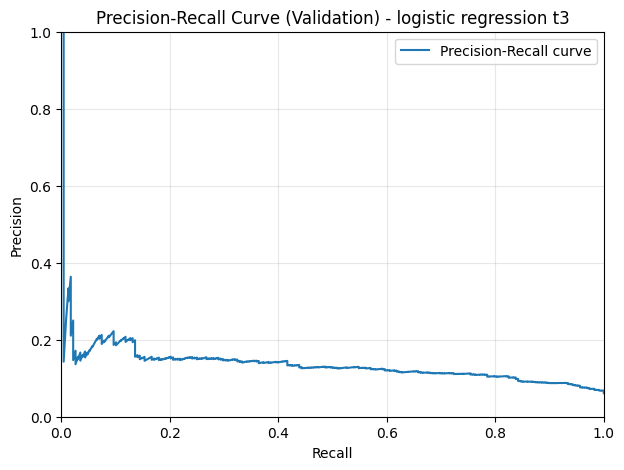

In [4]:
val_df = load_split("val")

threshold_table = plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    title=f"Precision-Recall Curve (Validation) - logistic regression {HORIZON}",
)

In [5]:
# inspect candidate operating points to pick a threshold
threshold_table = threshold_table.sort_values(by="recall", ascending=False)
threshold_table[threshold_table["precision"] >= 0.25].head(20)

,threshold,precision,recall
3708,0.905736,0.250000,0.021930
3713,0.923598,0.266667,0.017544
3717,0.931021,0.363636,0.017544
3716,0.930725,0.333333,0.017544
3714,0.923626,0.285714,0.017544
3715,0.924200,0.307692,0.017544
3712,0.921904,0.250000,0.017544
3718,0.939540,0.300000,0.013158
3719,0.940765,0.333333,0.013158
3720,0.950586,0.250000,0.008772


### Chosen threshold
Set `SELECTED_THRESHOLD` below based on the curve and table above.

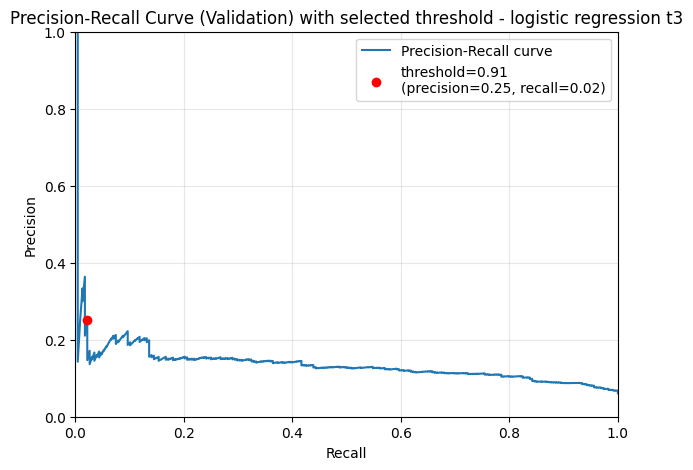

In [6]:
SELECTED_THRESHOLD = 0.905736

plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    threshold=SELECTED_THRESHOLD,
    title=f"Precision-Recall Curve (Validation) with selected threshold - logistic regression {HORIZON}",
);

## Final evaluation

In [7]:
evaluate_all_splits(model, feature_columns, threshold=SELECTED_THRESHOLD)

,pr_auc,precision,recall,f1,precision_at_k (k=90),recall_at_k (k=90)
train,0.131636,0.170213,0.005939,0.011478,0.177778,0.011878
val,0.137229,0.210526,0.017544,0.032389,0.188889,0.074561
test,0.152384,0.236842,0.032967,0.057878,0.222222,0.073260


## Save the model
Persist the fitted model together with its feature list and chosen threshold, so it can be reloaded for comparison and inference.

In [8]:
save_model(model, feature_columns, threshold=SELECTED_THRESHOLD)

Saved model to C:\Users\SVisbee\Repos\Credit_prediction_case\models\artifacts\log_reg_t3.joblib


WindowsPath('C:/Users/SVisbee/Repos/Credit_prediction_case/models/artifacts/log_reg_t3.joblib')